# Performance Reporting: The Core Metric Set

**Docker image**: `ml4t`

This notebook demonstrates the bridge from **ml4t-backtest** results to
**ml4t-diagnostic** performance analysis — computing and visualizing the
core metric set defined in Section 16.5.

**Learning Objectives**:
- Run a backtest with ml4t-backtest and extract the equity curve
- Bridge backtest results to `PortfolioAnalysis` for standardized metrics
- Compute return, risk, risk-adjusted, and trading behavior metrics
- Generate visual diagnostics: equity curve, drawdowns, rolling Sharpe, monthly heatmap
- Assess cost impact via gross-vs-net comparison and break-even costs

**Book Reference**: Chapter 16, Section 16.5 (Performance Metrics & Reporting)

**Prerequisites**: Familiarity with `04_single_asset_ml4t_backtest` (Engine/Strategy pattern)

## Setup

In [1]:
"""Performance Reporting — compute and visualize the core metric set from ml4t-backtest results."""

import warnings

warnings.filterwarnings("ignore")

import numpy as np
import polars as pl
from ml4t.backtest import (
    BacktestConfig,
    DataFeed,
    Engine,
    ExecutionMode,
    OrderSide,
    OrderType,
    Strategy,
)
from ml4t.backtest.analytics import MAEMFEAnalyzer, TradeAnalyzer
from ml4t.diagnostic.evaluation.factor import FactorData
from ml4t.diagnostic.integration import (
    BacktestReportMetadata,
    generate_tearsheet_from_result,
    portfolio_analysis_from_result,
)
from ml4t.diagnostic.visualization.backtest.tearsheet import generate_backtest_tearsheet
from ml4t.diagnostic.visualization.portfolio import (
    plot_cumulative_returns,
    plot_drawdown_underwater,
    plot_monthly_returns_heatmap,
    plot_returns_distribution,
    plot_rolling_sharpe,
)

from data import load_crypto_perps, load_ff_factors
from utils.paths import get_chapter_dir

In [2]:
# Production defaults — Papermill injects overrides after this cell
N_BARS = 0  # 0 = all bars; >0 limits dataset for fast testing

## 1. Run a Baseline Backtest

We reuse the RSI mean-reversion strategy from NB03, applied to BTC daily bars.
The strategy is deliberately simple — this notebook focuses on *reporting*,
not signal design.

In [3]:
class RSIMeanReversion(Strategy):
    """RSI mean-reversion: buy oversold, sell overbought."""

    def __init__(self, rsi_lower=30, rsi_upper=70, position_size=0.95):
        self.rsi_lower = rsi_lower
        self.rsi_upper = rsi_upper
        self.position_size = position_size

    def on_data(self, timestamp, data, context, broker):
        rsi = context.get("rsi")
        if rsi is None or np.isnan(rsi):
            return

        asset = "BTCUSDT"
        asset_data = data.get(asset)
        if asset_data is None:
            return

        position = broker.get_position(asset)
        is_long = position is not None and position.quantity > 0
        price = asset_data["close"]

        if not is_long and rsi < self.rsi_lower:
            qty = int(broker.cash * self.position_size / price)
            if qty > 0:
                broker.submit_order(asset, qty, OrderSide.BUY, OrderType.MARKET)
        elif is_long and rsi > self.rsi_upper:
            broker.submit_order(asset, position.quantity, OrderSide.SELL, OrderType.MARKET)

### Load data and compute RSI

In [4]:
# Load BTC data from local crypto dataset and resample to daily
_crypto = load_crypto_perps()
prices_df = (
    _crypto.filter(
        (pl.col("symbol") == "BTCUSDT")
        & (
            pl.col("timestamp")
            >= pl.lit("2020-01-01").str.to_datetime().dt.replace_time_zone("UTC")
        )
        & (pl.col("timestamp") < pl.lit("2024-01-01").str.to_datetime().dt.replace_time_zone("UTC"))
    )
    .sort("timestamp")
    .with_columns(pl.col("timestamp").dt.replace_time_zone(None))
    .group_by_dynamic("timestamp", every="1d")
    .agg(
        pl.col("open").first(),
        pl.col("high").max(),
        pl.col("low").min(),
        pl.col("close").last(),
        pl.col("volume").sum(),
    )
    .with_columns(pl.lit("BTCUSDT").alias("symbol"))
)
if N_BARS > 0:
    prices_df = prices_df.tail(N_BARS)
print(f"Loaded {len(prices_df):,} daily bars from local crypto dataset")

Loaded 1,461 daily bars from local crypto dataset


In [5]:
def compute_rsi(close: pl.Series, period: int = 14) -> pl.Series:
    """RSI via Wilder smoothing."""
    delta = close.diff()
    gain = delta.clip(lower_bound=0.0).fill_null(0.0)
    loss = (-delta).clip(lower_bound=0.0).fill_null(0.0)
    avg_gain = gain.ewm_mean(span=period * 2 - 1, adjust=False)
    avg_loss = loss.ewm_mean(span=period * 2 - 1, adjust=False)
    return 100 - (100 / (1 + avg_gain / avg_loss))


context_df = prices_df.select(["timestamp"]).with_columns(
    compute_rsi(prices_df["close"]).alias("rsi")
)

### Run with and without costs

We run the same strategy twice — with zero costs (gross) and with realistic
costs (net) — to quantify cost impact.

In [6]:
INITIAL_CASH = 100_000
COMMISSION_BPS = 10  # 10 bps
SLIPPAGE_BPS = 5  # 5 bps

# Gross backtest (zero costs)
config_gross = BacktestConfig(
    initial_cash=INITIAL_CASH,
    execution_mode=ExecutionMode.NEXT_BAR,
    commission_rate=0.0,
    slippage_rate=0.0,
)
engine_gross = Engine(
    feed=DataFeed(prices_df=prices_df, context_df=context_df),
    strategy=RSIMeanReversion(),
    config=config_gross,
)
results_gross = engine_gross.run()

# Net backtest (with costs)
config_net = BacktestConfig(
    initial_cash=INITIAL_CASH,
    execution_mode=ExecutionMode.NEXT_BAR,
    commission_rate=COMMISSION_BPS / 10_000,
    slippage_rate=SLIPPAGE_BPS / 10_000,
)
engine_net = Engine(
    feed=DataFeed(prices_df=prices_df, context_df=context_df),
    strategy=RSIMeanReversion(),
    config=config_net,
)
results_net = engine_net.run()

print(f"Gross final value: ${results_gross['final_value']:,.2f}")
print(f"Net final value:   ${results_net['final_value']:,.2f}")
print(f"Cost drag:         ${results_gross['final_value'] - results_net['final_value']:,.2f}")

Gross final value: $195,779.94
Net final value:   $188,641.34
Cost drag:         $7,138.60


## 2. Bridge: Backtest Results → PortfolioAnalysis

`BacktestResult.to_daily_returns()` converts the equity curve to a properly
aggregated daily return series — the standard input to `PortfolioAnalysis`.
For crypto (24/7 trading), every calendar day has a return. For equities,
pass `calendar="NYSE"` to align returns to trading days.

This bridge is the key integration point:

$$r_t = \frac{V_t - V_{t-1}}{V_{t-1}}$$

In [7]:
# One-liner bridge: extracts daily returns, infers periods_per_year from the
# calendar, and creates a PortfolioAnalysis with dates attached.
analysis_gross = portfolio_analysis_from_result(results_gross, calendar="crypto")
analysis_net = portfolio_analysis_from_result(results_net, calendar="crypto")

# We also keep numpy arrays for direct use in later sections
returns_gross = analysis_gross.returns
returns_net = analysis_net.returns

# Equity values for turnover computation
values_net = np.array(results_net["equity"].values)

print(f"Return series length: {len(returns_net):,} days")
dates = analysis_net.dates.to_list()
print(f"Date range: {dates[0]} to {dates[-1]}")

Return series length: 1,461 days
Date range: 2020-01-01 to 2023-12-31


## 3. Return Metrics

**Cumulative Return**: Total gain over the evaluation period.

$$R_{\text{cumulative}} = \prod_{t=1}^{T}(1 + r_t) - 1$$

**CAGR**: Annualized geometric return.

$$\text{CAGR} = \left(\frac{V_T}{V_0}\right)^{365/T} - 1$$

**Hit Rate**: Fraction of days with positive returns.

In [8]:
metrics_gross = analysis_gross.compute_summary_stats()
metrics_net = analysis_net.compute_summary_stats()

**Return metrics — gross vs net of costs:**

In [9]:
pl.DataFrame(
    {
        "metric": ["Total return", "Annual return (CAGR)", "Hit rate"],
        "gross": [
            metrics_gross.total_return,
            metrics_gross.annual_return,
            metrics_gross.win_rate,
        ],
        "net": [
            metrics_net.total_return,
            metrics_net.annual_return,
            metrics_net.win_rate,
        ],
    }
)

metric,gross,net
str,f64,f64
"""Total return""",0.957799,0.886413
"""Annual return (CAGR)""",0.182748,0.171823
"""Hit rate""",0.181383,0.180698


## 4. Risk Metrics

**Annualized Volatility**: $\sigma = \sqrt{365} \times \text{std}(r_t)$

**Maximum Drawdown**: Largest peak-to-trough decline.

**Calmar Ratio**: $\text{Calmar} = \text{CAGR} / \text{MDD}$

In [10]:
dd_result = analysis_net.compute_drawdown_analysis()

**Risk metrics — gross vs net:**

In [11]:
pl.DataFrame(
    {
        "metric": ["Annual volatility", "Max drawdown", "Calmar ratio"],
        "gross": [
            metrics_gross.annual_volatility,
            metrics_gross.max_drawdown,
            metrics_gross.calmar_ratio,
        ],
        "net": [
            metrics_net.annual_volatility,
            metrics_net.max_drawdown,
            metrics_net.calmar_ratio,
        ],
    }
)

metric,gross,net
str,f64,f64
"""Annual volatility""",0.372653,0.379654
"""Max drawdown""",-0.44008,-0.452595
"""Calmar ratio""",0.41526,0.37964


In [12]:
print("--- Drawdown Analysis (Net) ---")
print(f"Max drawdown duration:   {dd_result.max_duration_days} days")
print(f"Avg drawdown duration:   {dd_result.avg_duration_days:.0f} days")
print(f"Number of drawdowns:     {dd_result.num_drawdowns}")

if dd_result.top_drawdowns:
    print("\nTop 3 Drawdowns:")
    for i, dd in enumerate(dd_result.top_drawdowns[:3]):
        recovery = f" → recovered {dd.recovery_date}" if dd.recovery_date else " (unrecovered)"
        print(f"  {i + 1}. {dd.depth:.1%} from {dd.peak_date} to {dd.valley_date}{recovery}")

--- Drawdown Analysis (Net) ---
Max drawdown duration:   174 days
Avg drawdown duration:   27 days
Number of drawdowns:     10

Top 3 Drawdowns:
  1. -45.3% from 2022-05-31 to 2022-11-21 (unrecovered)
  2. -28.7% from 2021-05-17 to 2021-07-20 → recovered 2022-03-27
  3. -12.0% from 2020-03-26 to 2020-03-29 → recovered 2020-04-02


## 5. Risk-Adjusted Metrics

**Sharpe Ratio**: $SR = E[R - R_f] / \sigma_R$

**Sortino Ratio**: Uses only downside deviation.

Section 16.5 warns that the Sharpe ratio's standard error is often understated.
See `11_sharpe_ratio_inference` for Lo's autocorrelation correction and
confidence intervals.

**Risk-adjusted metrics — gross vs net:**

In [13]:
pl.DataFrame(
    {
        "metric": ["Sharpe ratio", "Sortino ratio", "Omega ratio"],
        "gross": [
            metrics_gross.sharpe_ratio,
            metrics_gross.sortino_ratio,
            metrics_gross.omega_ratio,
        ],
        "net": [
            metrics_net.sharpe_ratio,
            metrics_net.sortino_ratio,
            metrics_net.omega_ratio,
        ],
    }
)

# Distribution moments (affect SR inference)
dist = analysis_net.compute_returns_distribution()
print("\n--- Return Distribution (Net) ---")
print(
    f"Skewness:    {dist.skewness:>8.3f}  {'(negative → crash risk)' if dist.skewness < 0 else ''}"
)
print(f"Kurtosis:    {dist.kurtosis:>8.2f}  {'(fat tails)' if dist.kurtosis > 3 else ''}")
print(f"VaR 95%:     {dist.var_95:>8.2%}")
print(f"CVaR 95%:    {dist.cvar_95:>8.2%}")


--- Return Distribution (Net) ---
Skewness:       0.719  
Kurtosis:       15.93  (fat tails)
VaR 95%:       -2.38%
CVaR 95%:      -4.90%


## 6. Trading Behavior Metrics

These metrics characterize *how* the strategy trades, not just what it earns.

**Turnover**: Fraction of portfolio traded per period.

**Gross/Net Exposure**: Position sizing and leverage.

In [14]:
trades = results_net.get("trades", [])

if trades:
    analyzer = TradeAnalyzer(trades)
    n_years = len(returns_net) / 365

    # Compute turnover from trades
    total_traded = sum(
        abs(t.quantity * t.entry_price) + abs(t.quantity * t.exit_price) for t in trades
    )
    avg_equity = np.mean(values_net)
    annual_turnover = (total_traded / avg_equity) / n_years

    print("=== Trading Behavior ===")
    print(f"Total trades:            {analyzer.num_trades}")
    print(f"Win rate:                {analyzer.win_rate:.1%}")
    print(f"Profit factor:           {analyzer.profit_factor:.2f}")
    print(f"Avg bars held:           {analyzer.avg_bars_held:.1f}")
    print(f"Annual turnover:         {annual_turnover:.0%}")
    print(f"Trades per year:         {analyzer.num_trades / n_years:.1f}")

    # Percentage-based per-trade metrics (direction-aware)
    print("\n--- Per-Trade Return Metrics (percentage-based) ---")
    print(f"Avg trade return:        {analyzer.avg_trade:.2%}")
    print(f"Avg win:                 {analyzer.avg_win:.2%}")
    print(f"Avg loss:                {analyzer.avg_loss:.2%}")
    print(f"Largest win:             {analyzer.largest_win:.2%}")
    print(f"Largest loss:            {analyzer.largest_loss:.2%}")
    print(f"Payoff ratio:            {analyzer.payoff_ratio:.2f}")
    print(f"Expectancy:              {analyzer.expectancy:.2%}")

    # Cost decomposition from result.metrics
    m = results_net.metrics
    print("\n--- Cost Decomposition (built-in metrics) ---")
    print(f"Gross P&L:               ${m['total_gross_pnl']:>12,.2f}")
    print(f"Total costs:             ${m['total_costs']:>12,.2f}")
    print(f"Avg cost drag:           {m['avg_cost_drag']:.4%}")
    print(f"Gross profit factor:     {m['gross_profit_factor']:.2f}")
    print(f"Net profit factor:       {m['profit_factor']:.2f}")
else:
    print("No trades executed.")

=== Trading Behavior ===
Total trades:            7
Win rate:                71.4%
Profit factor:           2.01
Avg bars held:           74.9
Annual turnover:         305%
Trades per year:         1.7

--- Per-Trade Return Metrics (percentage-based) ---
Avg trade return:        15.24%
Avg win:                 31.07%
Avg loss:                -24.33%
Largest win:             84.27%
Largest loss:            -40.39%
Payoff ratio:            1.28
Expectancy:              15.24%

--- Cost Decomposition (built-in metrics) ---
Gross P&L:               $   90,719.21
Total costs:             $    3,116.83
Avg cost drag:           0.3229%
Gross profit factor:     2.04
Net profit factor:       2.01


In [15]:
# Trade log as structured DataFrame — the canonical export format
if trades:
    trades_df = results_net.to_trades_dataframe()
    print(f"Trade DataFrame: {trades_df.shape[0]} trades x {trades_df.shape[1]} columns")
    print(
        trades_df.select(
            [
                "symbol",
                "direction",
                "pnl",
                "pnl_percent",
                "gross_pnl",
                "cost_drag",
                "exit_reason",
                "bars_held",
            ]
        ).head(5)
    )

Trade DataFrame: 7 trades x 32 columns
shape: (5, 8)
┌─────────┬───────────┬─────────────┬────────────┬────────────┬───────────┬────────────┬───────────┐
│ symbol  ┆ direction ┆ pnl         ┆ pnl_percen ┆ gross_pnl  ┆ cost_drag ┆ exit_reaso ┆ bars_held │
│ ---     ┆ ---       ┆ ---         ┆ t          ┆ ---        ┆ ---       ┆ n          ┆ ---       │
│ str     ┆ str       ┆ f64         ┆ ---        ┆ f64        ┆ f64       ┆ ---        ┆ i32       │
│         ┆           ┆             ┆ f64        ┆            ┆           ┆ str        ┆           │
╞═════════╪═══════════╪═════════════╪════════════╪════════════╪═══════════╪════════════╪═══════════╡
│ BTCUSDT ┆ long      ┆ 10053.16361 ┆ 0.11313    ┆ 10244.5194 ┆ 0.00317   ┆ signal     ┆ 4         │
│         ┆           ┆             ┆            ┆ 8          ┆           ┆            ┆           │
│ BTCUSDT ┆ long      ┆ 84030.50283 ┆ 0.842662   ┆ 84314.9335 ┆ 0.004264  ┆ signal     ┆ 48        │
│         ┆           ┆ 4           ┆ 

## 6b. MFE/MAE Analysis

**Maximum Favorable Excursion (MFE)**: Best unrealized profit during a trade.

**Maximum Adverse Excursion (MAE)**: Worst unrealized loss during a trade.

The **edge ratio** (MFE/|MAE|) measures whether trades tend to go further
in your favor than against you. Values > 1 indicate a positive edge.
**Trade efficiency** measures how much of the MFE you actually capture.

In [16]:
if trades:
    mfe_analyzer = MAEMFEAnalyzer(trades)

    print("=== MFE/MAE Analysis ===")
    print(f"Edge Ratio (MFE/|MAE|):  {mfe_analyzer.edge_ratio:.2f}")
    print(f"Trade Efficiency:        {mfe_analyzer.efficiency:.2%}")
    print("")
    print("MAE Statistics:")
    print(f"  Mean:   {mfe_analyzer.mae_mean:.2%}")
    print(f"  Median: {mfe_analyzer.mae_median:.2%}")
    print("")
    print("MFE Statistics:")
    print(f"  Mean:   {mfe_analyzer.mfe_mean:.2%}")
    print(f"  Median: {mfe_analyzer.mfe_median:.2%}")

    # Optimal exit suggestions from the distribution
    levels = mfe_analyzer.optimal_exit_levels()
    print("")
    print("Suggested Optimal Exits:")
    print(f"  Stop Loss:    {levels['stop_loss']:.2%}")
    print(f"  Take Profit:  {levels['take_profit']:.2%}")
    print(f"  Risk/Reward:  {levels['risk_reward']:.2f}")

=== MFE/MAE Analysis ===
Edge Ratio (MFE/|MAE|):  1.59
Trade Efficiency:        -34.16%

MAE Statistics:
  Mean:   -14.51%
  Median: -5.53%

MFE Statistics:
  Mean:   23.06%
  Median: 11.38%

Suggested Optimal Exits:
  Stop Loss:    -11.64%
  Take Profit:  8.55%
  Risk/Reward:  0.73


**Exit-reason breakdown** — why each round-trip closed:

In [17]:
if trades:
    exit_reasons = (
        trades_df.group_by("exit_reason")
        .agg(
            n=pl.len(),
            avg_pnl=pl.col("pnl").mean(),
            total_pnl=pl.col("pnl").sum(),
            win_rate=(pl.col("pnl") > 0).mean(),
        )
        .sort("n", descending=True)
    )
    # Bare expression inside `if:` is not auto-displayed by IPython
    # (last_expr only fires for top-level expression statements).
    from IPython.display import display

    display(exit_reasons)
else:
    print("No trades — exit-reason breakdown unavailable.")

exit_reason,n,avg_pnl,total_pnl,win_rate
str,u32,f64,f64,f64
"""signal""",7,12663.048881,88641.342164,0.714286


## 7. Cost Impact Analysis

**Gross vs Net Returns**: Pre- and post-cost performance.

**Break-Even Costs**: The cost level that reduces CAGR to zero.

$$\text{Break-Even} = \frac{\text{Gross CAGR}}{\text{Annual Turnover}}$$

If break-even costs are below realistic cost estimates, the strategy is
not implementable.

**Exposure and cost capacity** — the §16.5 metric contract also lists gross
and net exposure and a cost-capacity quantity. This notebook runs a
single-asset long-only strategy on BTC, so gross and net exposure both
trivially equal the long position ratio (no offsetting shorts, no leverage)
and we therefore report break-even cost (NB14 carries this for the §16.4
baseline) as the practical cost-capacity proxy.

In [18]:
cost_drag_return = metrics_gross.annual_return - metrics_net.annual_return
cost_drag_sharpe = metrics_gross.sharpe_ratio - metrics_net.sharpe_ratio

**Cost impact** — gross vs net with the implied cost drag per metric:

In [19]:
pl.DataFrame(
    {
        "metric": ["CAGR", "Sharpe ratio"],
        "gross": [metrics_gross.annual_return, metrics_gross.sharpe_ratio],
        "net": [metrics_net.annual_return, metrics_net.sharpe_ratio],
        "drag": [cost_drag_return, cost_drag_sharpe],
    }
)

# Break-even cost estimate
if trades and annual_turnover > 0 and metrics_gross.annual_return > 0:
    breakeven_bps = (metrics_gross.annual_return / annual_turnover) * 10_000
    total_cost_bps = COMMISSION_BPS + SLIPPAGE_BPS
    print(f"\nBreak-even cost:         {breakeven_bps:.1f} bps per unit turnover")
    print(f"Actual cost assumed:     {total_cost_bps} bps")
    print(f"Cost margin:             {breakeven_bps - total_cost_bps:.1f} bps")
    if breakeven_bps < total_cost_bps:
        print("WARNING: Strategy does not survive transaction costs.")
else:
    print("\nBreak-even: N/A (no positive gross return or no trades)")


Break-even cost:         598.9 bps per unit turnover
Actual cost assumed:     15 bps
Cost margin:             583.9 bps


## 8. Visual Diagnostics

Section 16.5 specifies four standard visual elements for a backtest report:

1. Cumulative return plot with drawdown shading
2. Rolling 12-month Sharpe ratio
3. Monthly return heatmap
4. Return distribution

### Equity Curve and Drawdowns

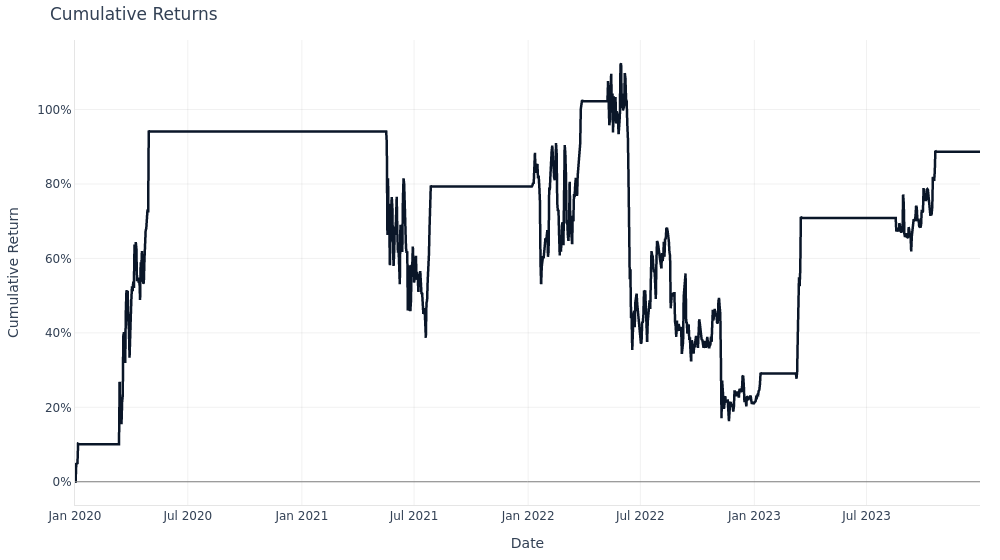

In [20]:
fig = plot_cumulative_returns(analysis_net)
fig.show()

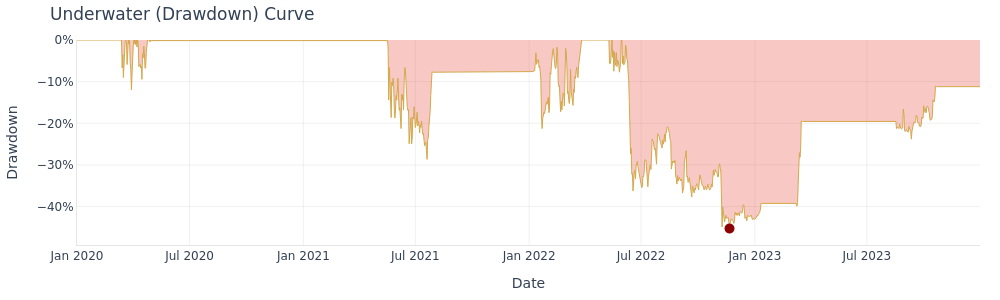

In [21]:
fig = plot_drawdown_underwater(analysis=analysis_net)
fig.show()

### Rolling 12-Month Sharpe Ratio

A declining rolling Sharpe warns of regime change or signal decay.
Sustained Sharpe below zero during extended periods indicates structural weakness.

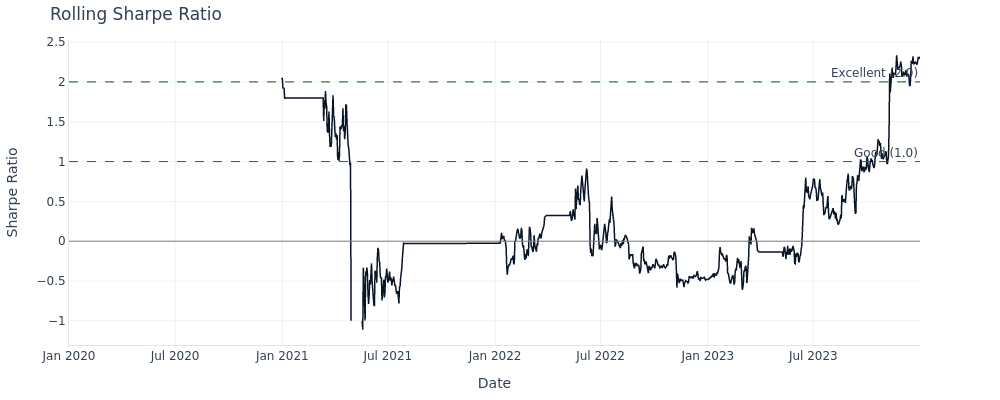

In [22]:
rolling = analysis_net.compute_rolling_metrics(windows=[365], metrics=["sharpe"])
fig = plot_rolling_sharpe(rolling_result=rolling)
fig.show()

### Monthly Return Heatmap

Reveals seasonal patterns and identifies problem months.

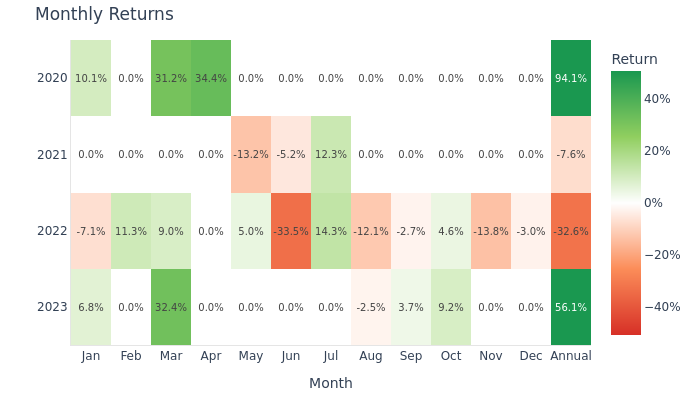

In [23]:
fig = plot_monthly_returns_heatmap(analysis_net)
fig.show()

### Return Distribution

Left skew and fat tails affect Sharpe ratio inference.

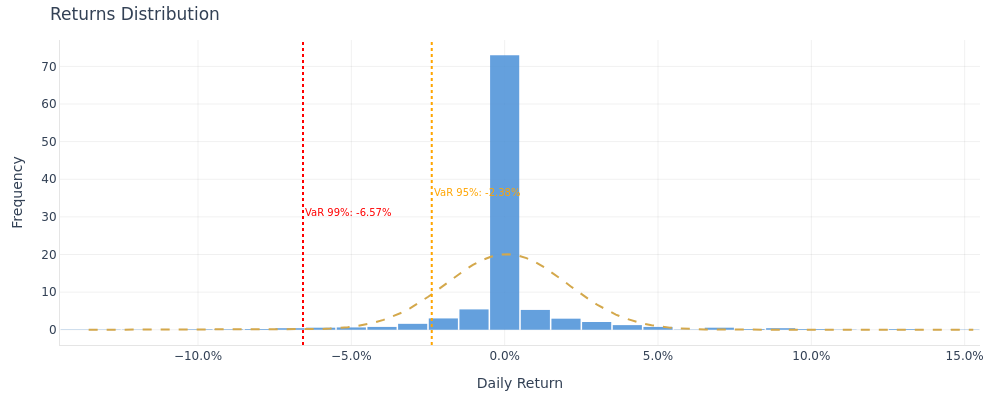

In [24]:
fig = plot_returns_distribution(analysis=analysis_net)
fig.show()

## 9. Standard Report Table

Assembling the Section 16.5 summary table programmatically.
This is the minimum metric set for any backtest report.

In [25]:
report = {
    "CAGR (gross)": f"{metrics_gross.annual_return:.2%}",
    "CAGR (net)": f"{metrics_net.annual_return:.2%}",
    "Annual Volatility": f"{metrics_net.annual_volatility:.2%}",
    "Sharpe Ratio (gross)": f"{metrics_gross.sharpe_ratio:.2f}",
    "Sharpe Ratio (net)": f"{metrics_net.sharpe_ratio:.2f}",
    "Sortino Ratio (net)": f"{metrics_net.sortino_ratio:.2f}",
    "Max Drawdown": f"{metrics_net.max_drawdown:.2%}",
    "Max DD Duration": f"{dd_result.max_duration_days} days",
    "Calmar Ratio": f"{metrics_net.calmar_ratio:.2f}",
}

if trades:
    report["Trades"] = str(analyzer.num_trades)
    report["Win Rate"] = f"{analyzer.win_rate:.1%}"
    report["Profit Factor"] = f"{analyzer.profit_factor:.2f}"
    report["Payoff Ratio"] = f"{analyzer.payoff_ratio:.2f}"
    report["Expectancy"] = f"{analyzer.expectancy:.2%}"
    report["Avg Cost Drag"] = f"{m['avg_cost_drag']:.4%}"
    report["Annual Turnover"] = f"{annual_turnover:.0%}"

report_df = pl.DataFrame({"Metric": list(report.keys()), "Value": list(report.values())})

**Backtest report — RSI mean reversion on BTC** (canonical §16.5 metric set):

In [26]:
report_df

Metric,Value
str,str
"""CAGR (gross)""","""18.27%"""
"""CAGR (net)""","""17.18%"""
"""Annual Volatility""","""37.97%"""
"""Sharpe Ratio (gross)""","""0.64"""
"""Sharpe Ratio (net)""","""0.61"""
…,…
"""Profit Factor""","""2.01"""
"""Payoff Ratio""","""1.28"""
"""Expectancy""","""15.24%"""


In [27]:
# Side-by-side gross vs net comparison
comparison = pl.DataFrame(
    {
        "Metric": [
            "CAGR",
            "Annual Volatility",
            "Sharpe Ratio",
            "Sortino Ratio",
            "Max Drawdown",
            "Calmar Ratio",
            "Omega Ratio",
        ],
        "Gross": [
            f"{metrics_gross.annual_return:.2%}",
            f"{metrics_gross.annual_volatility:.2%}",
            f"{metrics_gross.sharpe_ratio:.2f}",
            f"{metrics_gross.sortino_ratio:.2f}",
            f"{metrics_gross.max_drawdown:.2%}",
            f"{metrics_gross.calmar_ratio:.2f}",
            f"{metrics_gross.omega_ratio:.2f}",
        ],
        "Net": [
            f"{metrics_net.annual_return:.2%}",
            f"{metrics_net.annual_volatility:.2%}",
            f"{metrics_net.sharpe_ratio:.2f}",
            f"{metrics_net.sortino_ratio:.2f}",
            f"{metrics_net.max_drawdown:.2%}",
            f"{metrics_net.calmar_ratio:.2f}",
            f"{metrics_net.omega_ratio:.2f}",
        ],
    }
)

**Side-by-side gross vs net comparison** (string-formatted for the report):

In [28]:
comparison

Metric,Gross,Net
str,str,str
"""CAGR""","""18.27%""","""17.18%"""
"""Annual Volatility""","""37.27%""","""37.97%"""
"""Sharpe Ratio""","""0.64""","""0.61"""
"""Sortino Ratio""","""0.42""","""0.40"""
"""Max Drawdown""","""-44.01%""","""-45.26%"""
"""Calmar Ratio""","""0.42""","""0.38"""
"""Omega Ratio""","""1.19""","""1.18"""


## 10. Automated Tear Sheet Generation

The cumulative-return, drawdown, rolling-Sharpe, monthly-heatmap, and
returns-distribution figures shown inline in the previous sections are
exactly the content that the tear sheet packages — `ml4t-diagnostic` exposes
the *same* surface in two delivery modes:

- **Inline figures** (sections 6–9 above) — call individual plot functions
  on a `PortfolioAnalysis` and render them as standard cell outputs while
  you iterate.
- **Self-contained HTML** (this section) — call
  `generate_tearsheet_from_result()` to bundle every panel plus the
  validation tab into a single tabbed page that ships to a stakeholder or
  gets archived alongside a model.

`ml4t-diagnostic` v0.1.0b4 provides a 6-tab interactive dashboard:

| Tab | Question It Answers | Conditional |
|-----|---------------------|-------------|
| **Overview** | Did it work? | Always |
| **Performance** | How did the PnL behave? | Always |
| **Trading** | What did implementation cost? | Always |
| **Validation** | Should I trust it? (DSR, bootstrap) | Always |
| **ML** | Did the model translate to trades? | Predictions provided |
| **Factors** | What exposures explain it? | Factor data provided |

Two entry points: `generate_tearsheet_from_result()` for live BacktestResult
objects (teaching notebooks), and `generate_tearsheet_from_run_artifacts()`
for saved run directories (case study analysis).

In [29]:
output_dir = get_chapter_dir(16) / "output"
output_dir.mkdir(parents=True, exist_ok=True)

metadata = BacktestReportMetadata(
    title="RSI Mean Reversion on BTC",
    strategy_name="RSI Mean Reversion",
    universe="BTC/USDT perpetual",
)

# generate_tearsheet_from_result() extracts all available data surfaces from
# the BacktestResult — trades, equity, fills, weights, predictions — and
# renders the 6-tab dashboard. Tabs that need unavailable data are hidden.
html = generate_tearsheet_from_result(
    result=results_net,
    template="full",
    calendar="crypto",
    report_metadata=metadata,
    output_path=str(output_dir / "backtest_tearsheet.html"),
)

print(f"Tearsheet saved to: {output_dir / 'backtest_tearsheet.html'}")
print(f"HTML size: {len(html):,} bytes")

Tearsheet saved to: 16_strategy_simulation/output/backtest_tearsheet.html
HTML size: 949,432 bytes


The 4 core tabs (Overview, Performance, Trading, Validation) render for any
backtest. The **Trading** tab shows the cost bridge (gross → net), turnover
timeline, and MFE/MAE. The **Validation** tab computes the Deflated Sharpe
Ratio and bootstrap confidence intervals — statistical rigor made visible.

### Enabling the Factors Tab

Passing `FactorData` enables a **Factors** tab that regresses strategy returns
against a factor model (e.g., Fama-French 5). This reveals whether returns are
explained by market exposures or represent genuine alpha. The factor data is
downloaded once via `ml4t-data` and stored locally.

In [30]:
# Note: the Fama-French factors below are a single-asset BTC strategy regressed
# against US-equity risk factors — this is an API demonstration of the tearsheet's
# factor-attribution tab, not a meaningful factor model for crypto returns.
# Load Fama-French 5-factor daily returns (downloaded via ml4t-data)
ff5 = load_ff_factors(dataset="ff5", frequency="daily")
factor_names = ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]

factor_data = FactorData(
    returns=ff5.select(["timestamp"] + factor_names),
    rf_rate=ff5.get_column("RF"),
    factor_names=factor_names,
    source="fama-french",
    frequency="daily",
)

# Pass factor_data to enable the Factors tab
html_with_factors = generate_backtest_tearsheet(
    returns=analysis_net.returns,
    trades=results_net.to_trades_dataframe(),
    equity_curve=results_net.to_equity_dataframe(),
    metrics=results_net.metrics,
    factor_data=factor_data,
    report_metadata=metadata,
    template="full",
    output_path=str(output_dir / "backtest_tearsheet_with_factors.html"),
)

print(f"Factor-enriched tearsheet: {output_dir / 'backtest_tearsheet_with_factors.html'}")
print(f"HTML size: {len(html_with_factors):,} bytes")

Factor-enriched tearsheet: 16_strategy_simulation/output/backtest_tearsheet_with_factors.html
HTML size: 861,030 bytes


For this crypto strategy, we expect minimal factor loadings — BTC is not
explained by equity factors. For equity strategies (ETFs, US firms, S&P 500),
the Factors tab reveals whether alpha survives after accounting for market,
size, value, profitability, and investment exposures.

## Key Takeaways

1. **The bridge is a one-liner**: `portfolio_analysis_from_result(result, calendar=...)`
   extracts daily returns, infers annualization, and creates a `PortfolioAnalysis`.

2. **Always report gross AND net metrics**: Cost drag is the difference between
   what your signal earns and what you keep. Break-even costs tell you whether
   the strategy survives implementation.

3. **MFE/MAE reveals exit quality**: The edge ratio and trade efficiency show
   whether your exits capture the available move. Suggested stop/target levels
   are derived from the actual trade distribution, not arbitrary thresholds.

4. **The 6-tab tearsheet adapts to available data**: `generate_tearsheet_from_result()`
   renders the core 4 tabs from any BacktestResult. Pass `FactorData` to enable
   the Factors tab; the ML tab appears when predictions are available.

5. **Visual diagnostics reveal what summary stats hide**: Rolling Sharpe shows
   regime sensitivity; the heatmap shows seasonal patterns; the distribution
   shows tail risk that affects inference (see `11_sharpe_ratio_inference`).

**Next**: `11_sharpe_ratio_inference` for statistical significance testing.
**Book**: Section 16.5 discusses metric interpretation and practitioner thresholds.